In [298]:
import pandas as pd  #for data preprocessing, cleaning and feature engineering
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [299]:
# Data collection and Integration
files = [
    "./Dataset/historicalemshourlyload-2019.xlsx",
    "./Dataset/historicalemshourlyload-2020.xlsx",
    "./Dataset/historicalemshourlyload-2021.xlsx",
    "./Dataset/historicalemshourlyload-2022.xlsx",
    "./Dataset/historicalemshourlyloadfor2023.xlsx",
    "./Dataset/historical-ems-hourly-load-for-april-2024.xlsx",
    "./Dataset/historical-ems-hourly-load-for-april-2025.xlsx",
    "./Dataset/historical-ems-hourly-load-for-april-2026.xlsx",
    "./Dataset/historical-ems-hourly-load-for-august-2024.xlsx",
    "./Dataset/historical-ems-hourly-load-for-august-2025.xlsx",
    "./Dataset/historical-ems-hourly-load-for-december-2024.xlsx",
    "./Dataset/historical-ems-hourly-load-for-december-2025.xlsx",
    "./Dataset/historical-ems-hourly-load-for-february-2025.xlsx",
    "./Dataset/historical-ems-hourly-load-for-february-2026.xlsx",
    "./Dataset/historical-ems-hourly-load-for-january-2025.xlsx",
    "./Dataset/historical-ems-hourly-load-for-january-2026.xlsx",
    "./Dataset/historical-ems-hourly-load-for-july-2024.xlsx",
    "./Dataset/historical-ems-hourly-load-for-july-2025.xlsx",
    "./Dataset/historical-ems-hourly-load-for-june-2024.xlsx",
    "./Dataset/historical-ems-hourly-load-for-june-2025.xlsx",
    "./Dataset/historical-ems-hourly-load-for-march-2025.xlsx",
    "./Dataset/historical-ems-hourly-load-for-march-2026.xlsx",
    "./Dataset/historical-ems-hourly-load-for-may-2024.xlsx",
    "./Dataset/historical-ems-hourly-load-for-may-2025.xlsx",
    "./Dataset/historical-ems-hourly-load-for-november-2024.xlsx",
    "./Dataset/historical-ems-hourly-load-for-november-2025.xlsx",
    "./Dataset/historical-ems-hourly-load-for-october-2024.xlsx",
    "./Dataset/historical-ems-hourly-load-for-october-2025.xlsx",
    "./Dataset/historical-ems-hourly-load-for-september-2024.xlsx",
    "./Dataset/historical-ems-hourly-load-for-september-2025.xlsx",
    "./Dataset/historicalemshourlyloadforfebruary2024.xlsx",
    "./Dataset/historicalemshourlyloadforjanuary2024.xlsx",
    "./Dataset/historicalemshourlyloadformarch2024.xlsx"
]

In [300]:
#Merge(conacate) all Electricity consumption data
merged_df = pd.DataFrame()

for file in files:
    df = pd.read_excel(file)
    merged_df = pd.concat([merged_df, df], ignore_index=True)

# Save Merged Data
merged_df.to_excel("./Dataset/Energy_consumption_2019_April2026.xlsx")

print("All files merged succesfully")

All files merged succesfully


In [301]:
# Load weather Data
weather_df = pd.read_excel("./Dataset/weather2019_april2026_california.xlsx")


In [302]:
# Ḍata Inforamtion
print("Merged Info about energy : ")
print(merged_df.info())
print("Weather Data Information - :")
print(weather_df.info())

Merged Info about energy : 
<class 'pandas.DataFrame'>
RangeIndex: 64247 entries, 0 to 64246
Data columns (total 12 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   Date                                        64247 non-null  datetime64[us]
 1   HR                                          64247 non-null  int64         
 2   PGE                                         64247 non-null  float64       
 3   SCE                                         64247 non-null  float64       
 4   SDGE                                        64247 non-null  float64       
 5   VEA                                         64247 non-null  float64       
 6   CAISO Total                                 17544 non-null  float64       
 7   Unnamed: 7                                  6 non-null      object        
 8   CAISO                                       46703 non-null  float64  

In [303]:
print("Energy Data : ")
print(merged_df.head())

print("Weather Data :")
print(weather_df.head())

Energy Data : 
        Date  HR          PGE          SCE         SDGE         VEA  \
0 2019-01-01   1  9844.620265  9928.001620  2088.453772   92.069996   
1 2019-01-01   2  9507.691745  9604.449654  1998.915397   92.659879   
2 2019-01-01   3  9251.837855  9340.780790  1934.057172   93.592896   
3 2019-01-01   4  9123.916881  9183.897175  1891.808751   97.052299   
4 2019-01-01   5  9156.274437  9170.727964  1898.794915  101.469059   

    CAISO Total                                         Unnamed: 7  CAISO  \
0  21953.146163  Note: The hourly load value at hour ending (HE...    NaN   
1  21203.716174                                                NaN    NaN   
2  20620.268525                                                NaN    NaN   
3  20296.675172                                                NaN    NaN   
4  20327.266153                                                NaN    NaN   

   Spring DST change occurs on March 9 in HE2  \
0                                         NaN 

In [304]:

merged_df["Date"] += pd.to_timedelta(merged_df["HR"] - 1, unit="h") # make DATE col Similar to Weather_df Time Col for merging
merged_df.head()


,Date,HR,PGE,SCE,SDGE,VEA,CAISO Total,Unnamed: 7,CAISO,Spring DST change occurs on March 9 in HE2,DST change occurs on March 8 at 2AM,Fall DST change occurs on 11/2/2025 at 1am
0,2019-01-01 00:00:00,1,9844.620265,9928.001620,2088.453772,92.069996,21953.146163,Note: The hourly load value at hour ending (HE...,NaN,NaN,NaN,NaN
1,2019-01-01 01:00:00,2,9507.691745,9604.449654,1998.915397,92.659879,21203.716174,NaN,NaN,NaN,NaN,NaN
2,2019-01-01 02:00:00,3,9251.837855,9340.780790,1934.057172,93.592896,20620.268525,NaN,NaN,NaN,NaN,NaN
3,2019-01-01 03:00:00,4,9123.916881,9183.897175,1891.808751,97.052299,20296.675172,NaN,NaN,NaN,NaN,NaN
4,2019-01-01 04:00:00,5,9156.274437,9170.727964,1898.794915,101.469059,20327.266153,NaN,NaN,NaN,NaN,NaN


In [305]:
#Internsection of merged_df and weather_df on DATE and TIME col

# Merge
final_df = pd.merge(
    merged_df,
    weather_df,
    left_on="Date",
    right_on="Time",
    how="inner"
)


final_df.head()

,Date,HR,PGE,SCE,SDGE,VEA,CAISO Total,Unnamed: 7,CAISO,Spring DST change occurs on March 9 in HE2,DST change occurs on March 8 at 2AM,Fall DST change occurs on 11/2/2025 at 1am,Time,Temperature,RelativeHumidity
0,2019-01-01 00:00:00,1,9844.620265,9928.001620,2088.453772,92.069996,21953.146163,Note: The hourly load value at hour ending (HE...,NaN,NaN,NaN,NaN,2019-01-01 00:00:00,15.3,49
1,2019-01-01 01:00:00,2,9507.691745,9604.449654,1998.915397,92.659879,21203.716174,NaN,NaN,NaN,NaN,NaN,2019-01-01 01:00:00,14.7,49
2,2019-01-01 02:00:00,3,9251.837855,9340.780790,1934.057172,93.592896,20620.268525,NaN,NaN,NaN,NaN,NaN,2019-01-01 02:00:00,13.2,55
3,2019-01-01 03:00:00,4,9123.916881,9183.897175,1891.808751,97.052299,20296.675172,NaN,NaN,NaN,NaN,NaN,2019-01-01 03:00:00,11.6,51
4,2019-01-01 04:00:00,5,9156.274437,9170.727964,1898.794915,101.469059,20327.266153,NaN,NaN,NaN,NaN,NaN,2019-01-01 04:00:00,10.2,38


In [306]:
final_df = final_df[["Date", "SCE", "Temperature", "RelativeHumidity"]]
final_df.rename(
    columns={"SCE": "California_consumption_MW"},  #column renaming
    inplace=True
)
final_df = final_df.sort_values(by="Date").reset_index(drop=True)
final_df.to_excel("./Dataset/final_data.xlsx")
final_df.head()


,Date,California_consumption_MW,Temperature,RelativeHumidity
0,2019-01-01 00:00:00,9928.001620,15.3,49
1,2019-01-01 01:00:00,9604.449654,14.7,49
2,2019-01-01 02:00:00,9340.780790,13.2,55
3,2019-01-01 03:00:00,9183.897175,11.6,51
4,2019-01-01 04:00:00,9170.727964,10.2,38


In [307]:
# shape of final df and rang)
print("Dimension : ", final_df.shape)
print("Starting Date : ", final_df["Date"].min())
print("Last Date :" , final_df["Date"].max())

Dimension :  (64247, 4)
Starting Date :  2019-01-01 00:00:00
Last Date : 2026-04-30 23:00:00


In [308]:
#Featur Engineering
# Previous hour
final_df["Lag_1H"] = final_df["California_consumption_MW"].shift(1)

# Previous day (same hour)
final_df["Lag_1D"] = final_df["California_consumption_MW"].shift(24)

# Previous week (same day, same hour)
final_df["Lag_1W"] = final_df["California_consumption_MW"].shift(24 * 7)
temp = final_df.set_index("Date")




In [309]:
final_df.head()

,Date,California_consumption_MW,Temperature,RelativeHumidity,Lag_1H,Lag_1D,Lag_1W
0,2019-01-01 00:00:00,9928.001620,15.3,49,NaN,NaN,NaN
1,2019-01-01 01:00:00,9604.449654,14.7,49,9928.001620,NaN,NaN
2,2019-01-01 02:00:00,9340.780790,13.2,55,9604.449654,NaN,NaN
3,2019-01-01 03:00:00,9183.897175,11.6,51,9340.780790,NaN,NaN
4,2019-01-01 04:00:00,9170.727964,10.2,38,9183.897175,NaN,NaN


In [310]:
#create time feature
def create_time_features(df):
    df["Hour"] = df["Date"].dt.hour
    df["DayOfWeek"] = df["Date"].dt.dayofweek
    df["Month"] = df["Date"].dt.month
    df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

    return df

create_time_features(final_df)

,Date,California_consumption_MW,Temperature,RelativeHumidity,Lag_1H,Lag_1D,Lag_1W,Hour,DayOfWeek,Month,IsWeekend
0,2019-01-01 00:00:00,9928.001620,15.3,49,NaN,NaN,NaN,0,1,1,0
1,2019-01-01 01:00:00,9604.449654,14.7,49,9928.001620,NaN,NaN,1,1,1,0
2,2019-01-01 02:00:00,9340.780790,13.2,55,9604.449654,NaN,NaN,2,1,1,0
3,2019-01-01 03:00:00,9183.897175,11.6,51,9340.780790,NaN,NaN,3,1,1,0
4,2019-01-01 04:00:00,9170.727964,10.2,38,9183.897175,NaN,NaN,4,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
64242,2026-04-30 19:00:00,12037.997950,23.2,44,11763.386070,11767.57907,12046.54221,19,3,4,0
64243,2026-04-30 20:00:00,12170.245750,25.3,41,12037.997950,12059.81288,12110.54455,20,3,4,0
64244,2026-04-30 21:00:00,12147.163800,25.1,43,12170.245750,11973.79996,11910.15215,21,3,4,0
64245,2026-04-30 22:00:00,11634.222390,24.0,47,12147.163800,11327.93291,11349.17207,22,3,4,0


In [311]:
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64247 entries, 0 to 64246
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       64247 non-null  datetime64[us]
 1   California_consumption_MW  64247 non-null  float64       
 2   Temperature                64247 non-null  float64       
 3   RelativeHumidity           64247 non-null  int64         
 4   Lag_1H                     64246 non-null  float64       
 5   Lag_1D                     64223 non-null  float64       
 6   Lag_1W                     64079 non-null  float64       
 7   Hour                       64247 non-null  int32         
 8   DayOfWeek                  64247 non-null  int32         
 9   Month                      64247 non-null  int32         
 10  IsWeekend                  64247 non-null  int64         
dtypes: datetime64[us](1), float64(5), int32(3), int64(2)
memory usage: 4.7 MB


In [312]:
final_df = final_df.dropna()  #Drop rows with null values
final_df.head()

,Date,California_consumption_MW,Temperature,RelativeHumidity,Lag_1H,Lag_1D,Lag_1W,Hour,DayOfWeek,Month,IsWeekend
168,2019-01-08 01:00:00,9444.276654,13.8,85,9827.790621,9004.361833,9928.001620,1,1,1,0
169,2019-01-08 02:00:00,9234.540707,13.4,88,9444.276654,8868.235332,9604.449654,2,1,1,0
170,2019-01-08 03:00:00,9210.413359,12.3,91,9234.540707,8879.184245,9340.780790,3,1,1,0
171,2019-01-08 04:00:00,9515.101154,11.4,93,9210.413359,9218.748793,9183.897175,4,1,1,0
172,2019-01-08 05:00:00,10218.945710,10.7,92,9515.101154,9983.597128,9170.727964,5,1,1,0


In [313]:
# Training the Model

#define input and target feature
X = final_df.drop(columns=["Date", "California_consumption_MW"])
y = final_df["California_consumption_MW"]

In [314]:
#splitting dataset (80% trainig / 20% testing)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

x_train.tail()

,Temperature,RelativeHumidity,Lag_1H,Lag_1D,Lag_1W,Hour,DayOfWeek,Month,IsWeekend
51426,16.8,43,12473.51412,12180.21159,12130.50363,18,1,11,0
51427,18.2,41,12278.20010,12085.45863,11801.59088,19,1,11,0
51428,19.4,32,12043.18711,11876.26420,11567.48205,20,1,11,0
51429,20.8,25,11875.41907,11562.61885,11266.73675,21,1,11,0
51430,21.9,21,11573.76590,11109.29314,10774.34810,22,1,11,0


In [315]:
#Model training using Random Forest Regresser
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [316]:
#Prediction on Testing Dataset
rf_pred = rf_model.predict(x_test)

In [317]:
# XGBoost Training
xgb_model = XGBRegressor( n_estimators=100,
    learning_rate=0.5,
    max_depth=6,
    random_state=42
)

# train
xgb_model.fit(x_train, y_train)
#test
xgb_pred = xgb_model.predict(x_test)

In [318]:
# Accuracy Calculateion of Model
# 1. Random Forest
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

# XGBoost
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

In [319]:
# Accuracy Comparison of both model
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "MAE": [rf_mae, xgb_mae],
    "RMSE": [rf_rmse, xgb_rmse],
    "R2 Score": [rf_r2, xgb_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Random Forest,351.149908,287846.650991,0.948675
1,XGBoost,346.071082,518.918755,0.951986


In [320]:
#comparison table of predicted values
comparison_table = pd.DataFrame({
    "Actual Value": y_test.reset_index(drop=True),
    "RF_Prediction": rf_pred,
    "XGB_Prediction": xgb_pred,
    "RF_Error": y_test.reset_index(drop=True) - rf_pred,
    "XGB_Error": y_test.reset_index(drop=True) - xgb_pred
})
comparison_table["RF_Abs_Error"] = abs(comparison_table["RF_Error"])
comparison_table["XGB_Abs_Error"] = abs(comparison_table["XGB_Error"])

comparison_table.head(10)

,Actual Value,RF_Prediction,XGB_Prediction,RF_Error,XGB_Error,RF_Abs_Error,XGB_Abs_Error
0,10662.343090,10502.450979,10438.545898,159.892111,223.797192,159.892111,223.797192
1,10211.766320,10122.372651,10142.243164,89.393669,69.523156,89.393669,69.523156
2,9808.106853,9879.899079,9897.975586,-71.792226,-89.868733,71.792226,89.868733
3,9702.507270,9602.654829,9635.560547,99.852441,66.946723,99.852441,66.946723
4,9584.549068,9604.296536,9665.925781,-19.747468,-81.376713,19.747468,81.376713
5,9610.064540,9649.701187,9771.236328,-39.636647,-161.171788,39.636647,161.171788
6,10194.918830,10145.620886,10223.674805,49.297944,-28.755975,49.297944,28.755975
7,10916.735910,10857.848729,10978.886719,58.887181,-62.150809,58.887181,62.150809
8,11839.390290,11613.881873,11610.814453,225.508417,228.575837,225.508417,228.575837
9,12984.410390,12915.929739,12368.217773,68.480651,616.192617,68.480651,616.192617


In [321]:
rf_better = (comparison_table["RF_Abs_Error"] < comparison_table["XGB_Abs_Error"]).sum()
xgb_better = (comparison_table["XGB_Abs_Error"] < comparison_table["RF_Abs_Error"]).sum()
same = (comparison_table["RF_Abs_Error"] == comparison_table["XGB_Abs_Error"]).sum()

print("RF Better :", rf_better)
print("XGB Better:", xgb_better)
print("Same      :", same)

RF Better : 6511
XGB Better: 6305
Same      : 0


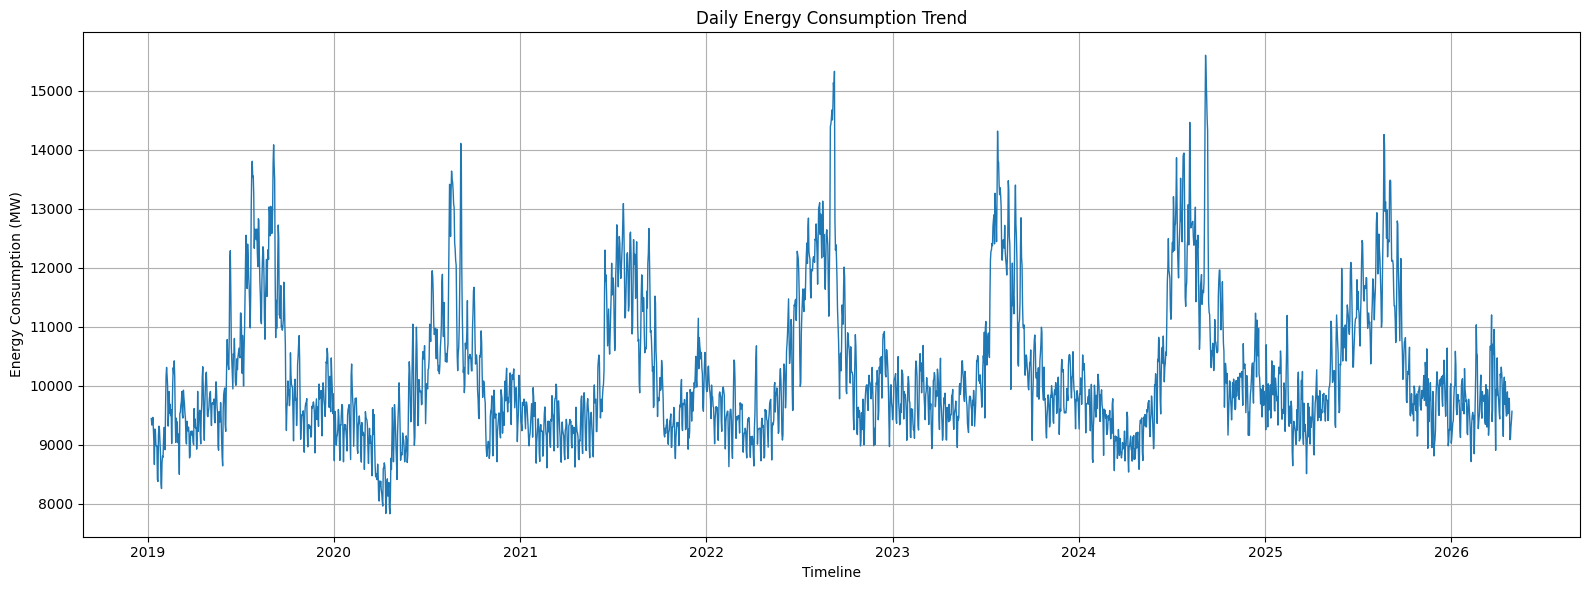

In [322]:
#visulization of Model Performance 
plt.figure(figsize=(16,6))

plt.plot(
    final_df["Date"][::24],
    final_df["California_consumption_MW"][::24],
    linewidth=1
)

plt.title("Daily Energy Consumption Trend")
plt.xlabel("Timeline")
plt.ylabel("Energy Consumption (MW)")
plt.grid(True)

plt.tight_layout()
plt.show()

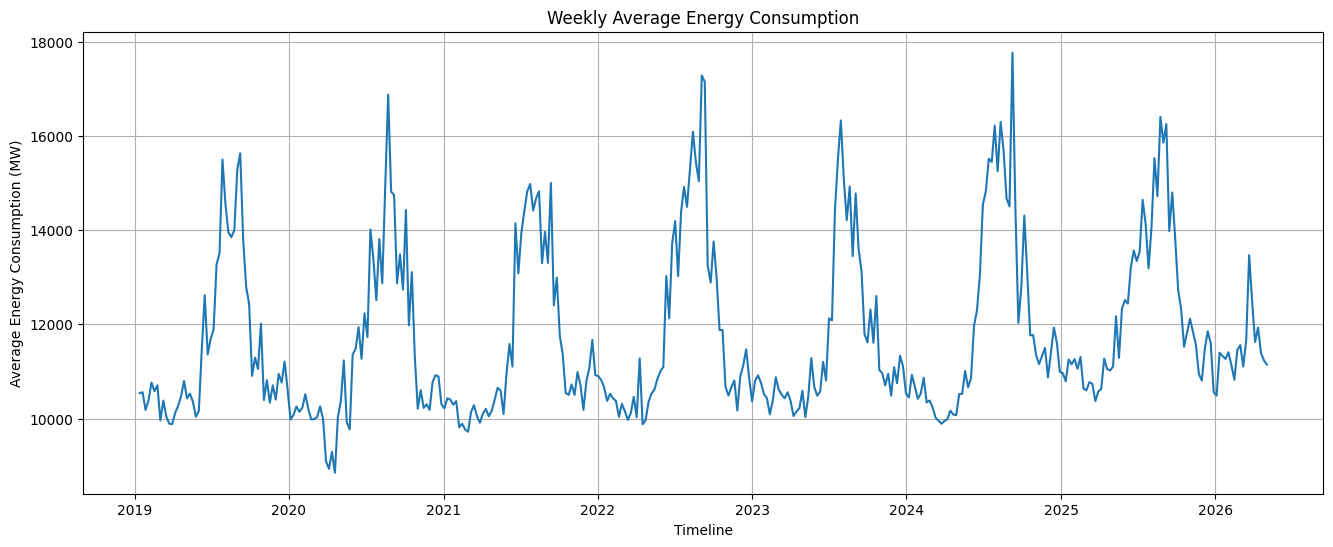

In [323]:
weekly_data = final_df.set_index("Date").resample("W")["California_consumption_MW"].mean()

plt.figure(figsize=(16,6))
plt.plot(weekly_data.index, weekly_data.values)

plt.title("Weekly Average Energy Consumption")
plt.xlabel("Timeline")
plt.ylabel("Average Energy Consumption (MW)")
plt.grid(True)

plt.show()

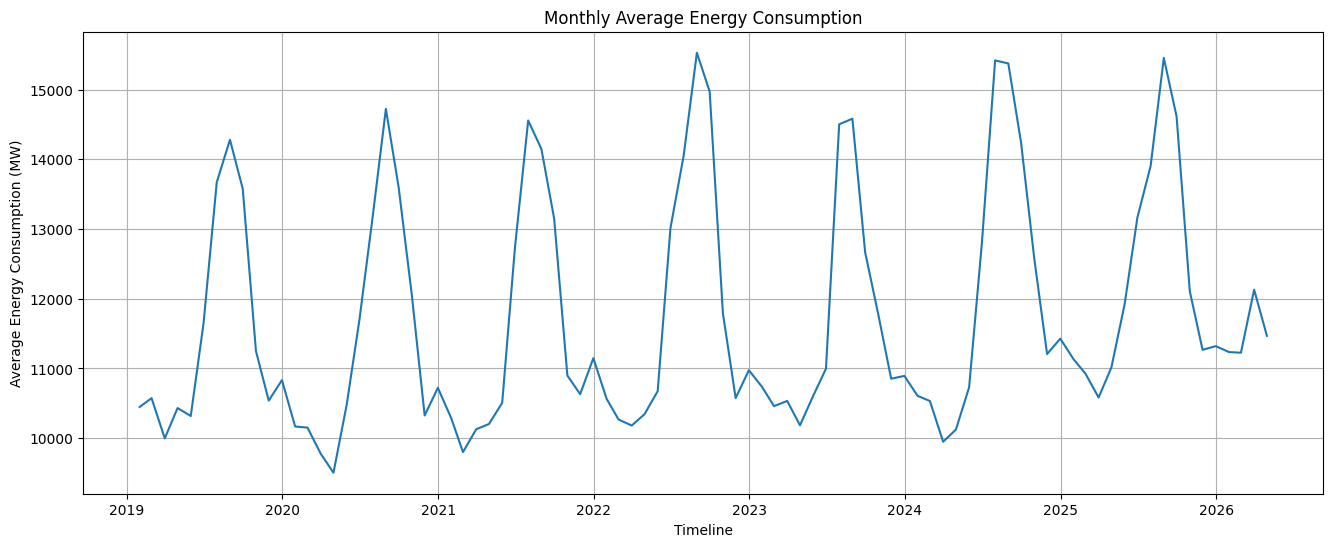

In [324]:
monthly_data = final_df.set_index("Date").resample("ME")["California_consumption_MW"].mean()

plt.figure(figsize=(16,6))
plt.plot(monthly_data.index, monthly_data.values)

plt.title("Monthly Average Energy Consumption")
plt.xlabel("Timeline")
plt.ylabel("Average Energy Consumption (MW)")
plt.grid(True)

plt.show()

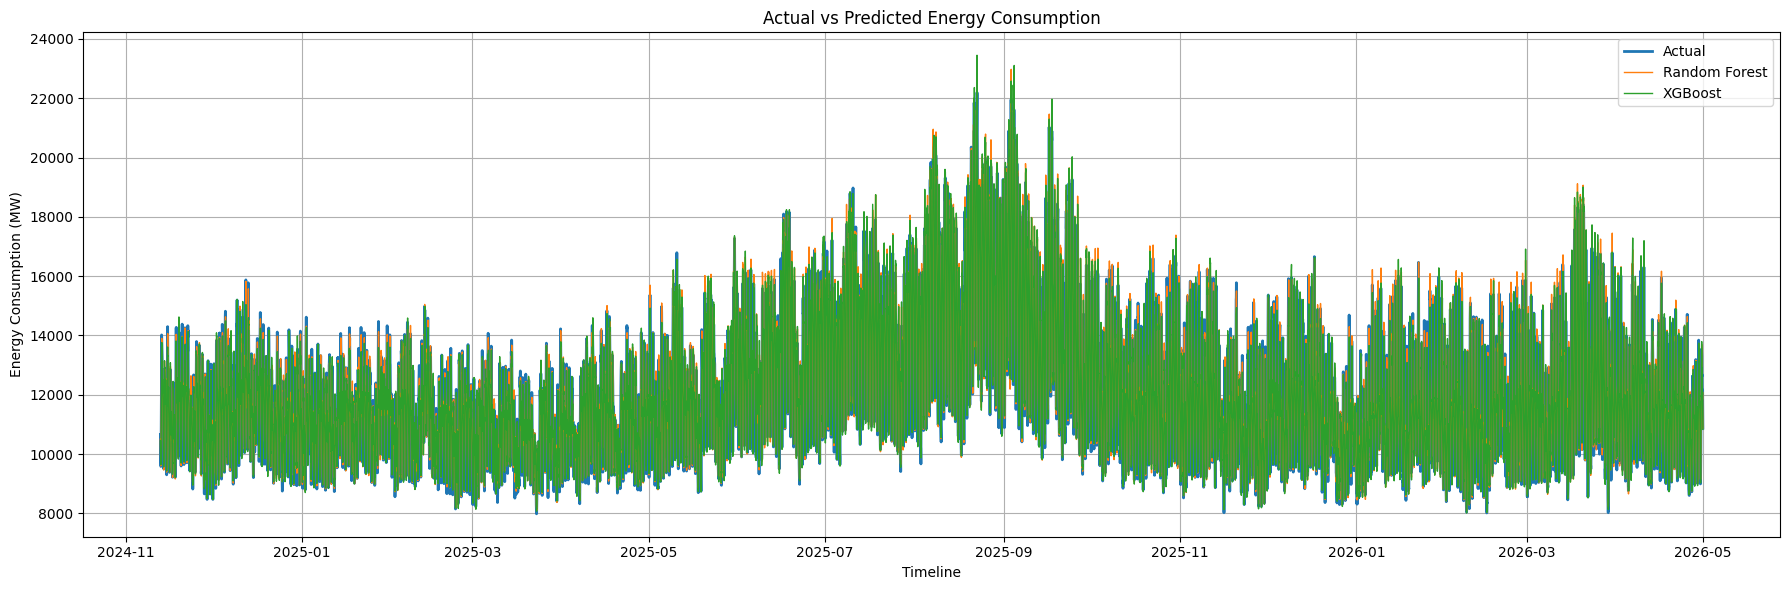

In [325]:

# Test timeline
test_dates = final_df["Date"].iloc[len(x_train):]

plt.figure(figsize=(18,6))

# Actual
plt.plot(test_dates, y_test, label="Actual", linewidth=2)

# Random Forest
plt.plot(test_dates, rf_pred, label="Random Forest", linewidth=1)

# XGBoost
plt.plot(test_dates, xgb_pred, label="XGBoost", linewidth=1)

plt.title("Actual vs Predicted Energy Consumption")
plt.xlabel("Timeline")
plt.ylabel("Energy Consumption (MW)")
plt.legend()

plt.grid(True)

plt.tight_layout()
plt.show()

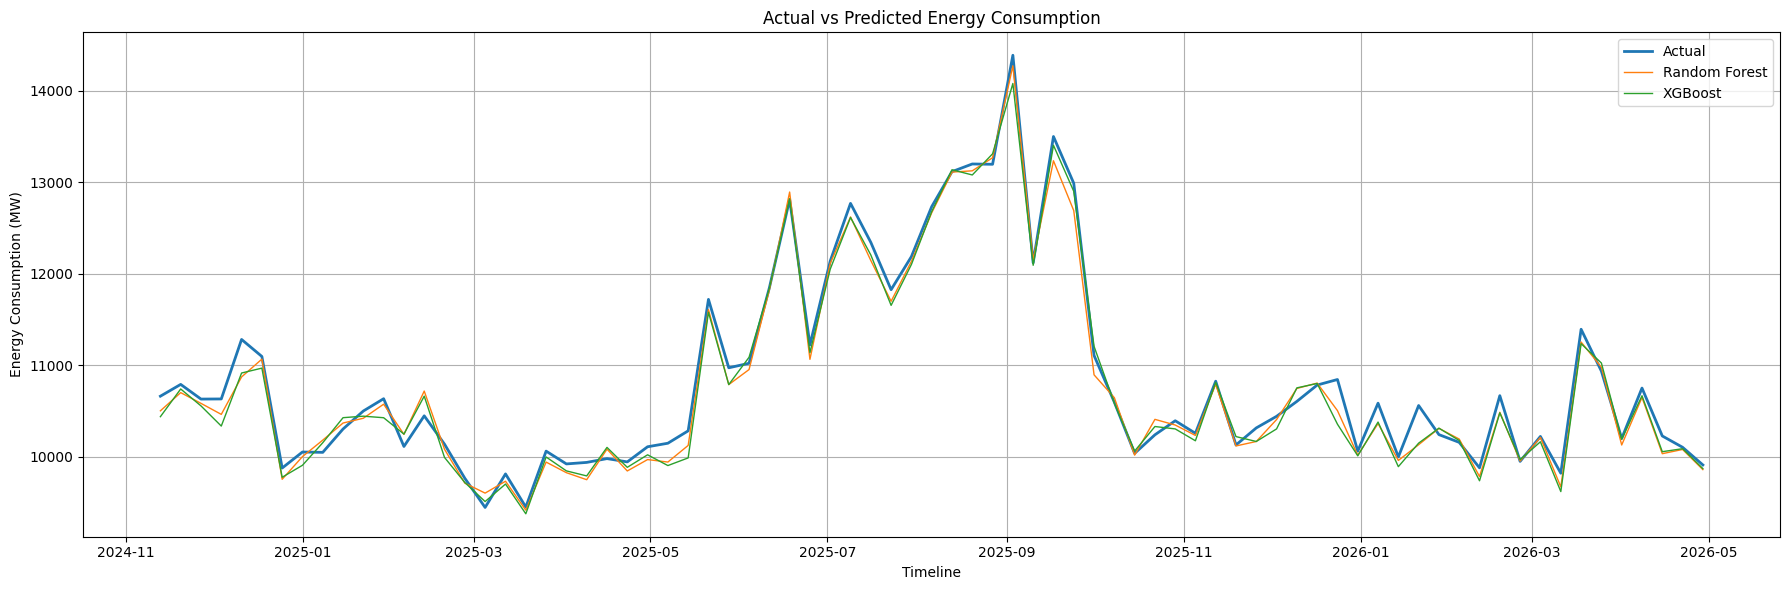

In [333]:
step = 168  # har 24th point (daily)

plt.figure(figsize=(18,6))

plt.plot(test_dates[::step], y_test.iloc[::step], label="Actual", linewidth=2)
plt.plot(test_dates[::step], rf_pred[::step], label="Random Forest", linewidth=1)
plt.plot(test_dates[::step], xgb_pred[::step], label="XGBoost", linewidth=1)

plt.title("Actual vs Predicted Energy Consumption")
plt.xlabel("Timeline")
plt.ylabel("Energy Consumption (MW)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [327]:
#Prediction for (may - 5th august2026)
prediction_df = pd.read_excel("./Dataset/new_weather_info.xlsx")
print(prediction_df.shape)
prediction_df.info()


(2328, 3)
<class 'pandas.DataFrame'>
RangeIndex: 2328 entries, 0 to 2327
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              2328 non-null   datetime64[us]
 1   Temperature       2328 non-null   float64       
 2   RelativeHumidity  2328 non-null   int64         
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 54.7 KB


In [328]:
#Create time feature
create_time_features(prediction_df)
prediction_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2328 entries, 0 to 2327
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              2328 non-null   datetime64[us]
 1   Temperature       2328 non-null   float64       
 2   RelativeHumidity  2328 non-null   int64         
 3   Hour              2328 non-null   int32         
 4   DayOfWeek         2328 non-null   int32         
 5   Month             2328 non-null   int32         
 6   IsWeekend         2328 non-null   int64         
dtypes: datetime64[us](1), float64(1), int32(3), int64(2)
memory usage: 100.2 KB


In [329]:
#add first lag feature
prediction_df.head()

,Date,Temperature,RelativeHumidity,Hour,DayOfWeek,Month,IsWeekend
0,2026-05-01 00:00:00,22.2,54,0,4,5,0
1,2026-05-01 01:00:00,20.9,57,1,4,5,0
2,2026-05-01 02:00:00,19.1,63,2,4,5,0
3,2026-05-01 03:00:00,17.9,68,3,4,5,0
4,2026-05-01 04:00:00,17.5,71,4,4,5,0


In [330]:
import numpy as np

# Prediction column create
prediction_df["California_consumption_MW"] = np.nan

for i in range(len(prediction_df)):

    # ---------- Lag Features ----------
    if i == 0:

        # First hour: use actual historical data
        prediction_df.loc[i, "Lag_1H"] = final_df["California_consumption_MW"].iloc[-1]
        prediction_df.loc[i, "Lag_1D"] = final_df["California_consumption_MW"].iloc[-24]
        prediction_df.loc[i, "Lag_1W"] = final_df["California_consumption_MW"].iloc[-168]

    else:

        # ---------- Lag 1 Hour ----------
        prediction_df.loc[i, "Lag_1H"] = prediction_df.loc[i-1, "California_consumption_MW"]

        # ---------- Lag 1 Day ----------
        if i < 24:
            prediction_df.loc[i, "Lag_1D"] = final_df["California_consumption_MW"].iloc[-24 + i]
        else:
            prediction_df.loc[i, "Lag_1D"] = prediction_df.loc[i-24, "California_consumption_MW"]

        # ---------- Lag 1 Week ----------
        if i < 168:
            prediction_df.loc[i, "Lag_1W"] = final_df["California_consumption_MW"].iloc[-168 + i]
        else:
            prediction_df.loc[i, "Lag_1W"] = prediction_df.loc[i-168, "California_consumption_MW"]

    # ---------- Model Input ----------
    X = prediction_df.loc[[i], [
        "Temperature",
        "RelativeHumidity",
        "Lag_1H",
        "Lag_1D",
        "Lag_1W",
        "Hour",
        "DayOfWeek",
        "Month",
        "IsWeekend"
    ]]

    # ---------- Predict ----------
    pred = xgb_model.predict(X)[0]

    # ---------- Save Prediction ----------
    prediction_df.loc[i, "California_consumption_MW"] = pred
   

In [331]:
prediction_df.loc[
    prediction_df["Date"].between("2026-06-30", "2026-08-02"),
    [
        "Date",
        "Temperature",
        "RelativeHumidity",
        "Lag_1H",
        "Lag_1D",
        "Lag_1W",
        "California_consumption_MW"
    ]
]


,Date,Temperature,RelativeHumidity,Lag_1H,Lag_1D,Lag_1W,California_consumption_MW
1440,2026-06-30 00:00:00,24.5,50,10559.193359,9604.595703,9752.332031,9944.271484
1441,2026-06-30 01:00:00,23.1,56,9944.271484,9226.208008,9318.974609,9542.564453
1442,2026-06-30 02:00:00,21.8,60,9542.564453,8962.882812,9033.874023,9241.904297
1443,2026-06-30 03:00:00,20.4,66,9241.904297,8874.956055,8930.370117,9047.260742
1444,2026-06-30 04:00:00,19.4,72,9047.260742,9060.458984,9087.799805,9141.230469
...,...,...,...,...,...,...,...
2228,2026-08-01 20:00:00,34.7,33,9994.468750,10141.530273,10279.389648,10020.276367
2229,2026-08-01 21:00:00,35.4,31,10020.276367,9784.761719,9929.659180,9779.962891
2230,2026-08-01 22:00:00,35.4,29,9779.962891,9632.052734,9509.749023,9477.763672
2231,2026-08-01 23:00:00,34.4,30,9477.763672,9119.823242,9069.456055,9166.983398


Text(0, 0.5, 'Predicted Consumption')

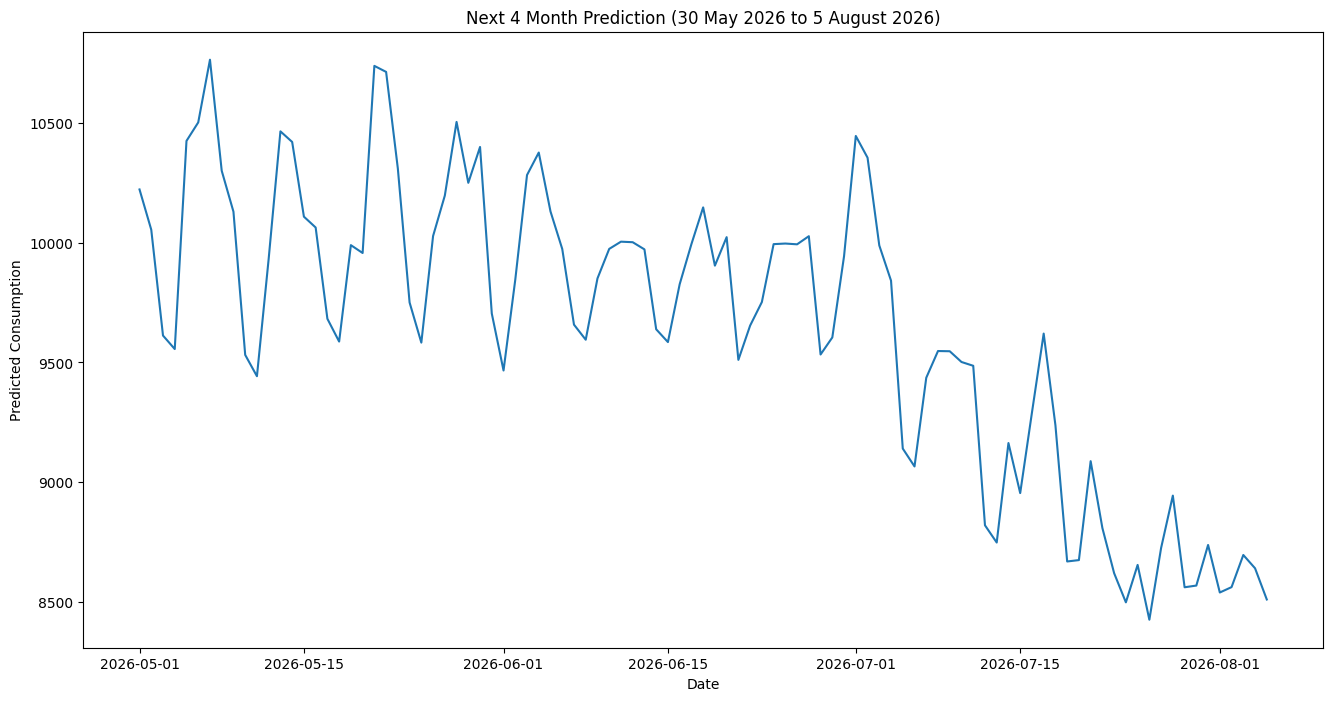

In [332]:
#plot the new prediction
plt.figure(figsize=(16,8))

st = 24

plt.plot(prediction_df["Date"][::st], prediction_df["California_consumption_MW"][::st],linewidth=1.5)
plt.title("Next 4 Month Prediction (30 May 2026 to 5 August 2026)")
plt.xlabel("Date")
plt.ylabel("Predicted Consumption")